In [ ]:
import pandas as pd
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
import pandas as pd

# Direct CSV download from FRED (up to 2023)
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=LORSGPORINQ659S"
data = pd.read_csv(url)
print(data.tail())

    observation_date  LORSGPORINQ659S
101       2022-07-01         5.500645
102       2022-10-01         4.636844
103       2023-01-01         6.287998
104       2023-04-01         7.279560
105       2023-07-01         7.020334


In [ ]:
data.rename(columns={'LORSGPORINQ659S': 'GDP_growth_rate'}, inplace=True)
data.rename(columns={'observation_date': 'DATE'}, inplace=True)


In [ ]:
new_rows = pd.DataFrame({
    'DATE': ['2023-10-01', '2024-01-01', '2024-04-01', '2024-07-01', '2024-10-01', '2025-01-01', '2025-04-01', '2025-07-01', '2025-10-01'],
    'GDP_growth_rate': [7.1, 7.5, 7.5, 6.6, 7.4, 7.0, 6.7, 8.4, 7.8]
})
data = pd.concat([data, new_rows], ignore_index=True)
print(data.tail(10))


           DATE  GDP_growth_rate
105  2023-07-01         7.020334
106  2023-10-01         7.100000
107  2024-01-01         7.500000
108  2024-04-01         7.500000
109  2024-07-01         6.600000
110  2024-10-01         7.400000
111  2025-01-01         7.000000
112  2025-04-01         6.700000
113  2025-07-01         8.400000
114  2025-10-01         7.800000


In [ ]:
data.head()

,DATE,GDP_growth_rate
0,1997-04-01,3.271867
1,1997-07-01,3.995211
2,1997-10-01,4.010855
3,1998-01-01,4.916954
4,1998-04-01,5.858280


In [ ]:
data.tail()

,DATE,GDP_growth_rate
110,2024-10-01,7.4
111,2025-01-01,7.0
112,2025-04-01,6.7
113,2025-07-01,8.4
114,2025-10-01,7.8


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DATE             115 non-null    object 
 1   GDP_growth_rate  115 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.9+ KB


<Axes: xlabel='GDP_growth_rate', ylabel='Count'>

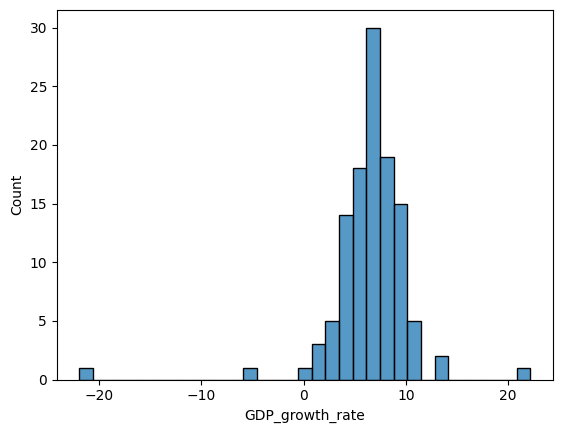

In [ ]:
sns.histplot(data=data['GDP_growth_rate'])

converting to date time format

In [ ]:
date=pd.to_datetime(data['DATE'])
data.head()

,DATE,GDP_growth_rate
0,1997-04-01,3.271867
1,1997-07-01,3.995211
2,1997-10-01,4.010855
3,1998-01-01,4.916954
4,1998-04-01,5.858280


check for missing value

In [ ]:
data.isnull().sum()

,0
DATE,0
GDP_growth_rate,0


statistical property of data

In [ ]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
GDP_growth_rate,115.0,6.55093,4.011766,-21.92112,5.261965,6.902816,8.516391,22.16256


In [ ]:
data.shape

(115, 2)

GDP growth rate over time

In [ ]:
fig = go.Figure(data=go.Heatmap(
                   z=[data['GDP_growth_rate']],
                   x=data.index,
                   y=['GDP_growth_rate'],
                   colorscale='spectral'))

fig.update_layout(title='GDP Growth over Time',
                  xaxis_title='Time Period',
                  yaxis_title='')

fig.show()

**recession means the decline in the circulation of money for two consecutive** **quarters**

In [ ]:
# Calculate recession based on quarterly GDP growth
data['Recession'] = ((data['GDP_growth_rate'] < 0) & (data['GDP_growth_rate'].shift(1) < 0))
data.head()
# shift(1) means previous pd

,DATE,GDP_growth_rate,Recession
0,1997-04-01,3.271867,False
1,1997-07-01,3.995211,False
2,1997-10-01,4.010855,False
3,1998-01-01,4.916954,False
4,1998-04-01,5.858280,False


In [ ]:
data.groupby('Recession').count()

,DATE,GDP_growth_rate
Recession,,
False,114,114
True,1,1


plotting the graph

In [ ]:
# Plot the GDP growth and recession data
fig = go.Figure()
fig.add_trace(go.Scatter(x=data.index,
                         y=data['GDP_growth_rate'],
                         name='GDP_growth_rate',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=data[data['Recession']].index,
                         y=data[data['Recession']]['GDP_growth_rate'],
                         name='Recession', line=dict(color='red', width=2)))

fig.update_layout(title='GDP Growth and Recession over Time (Quarterly Data)',
                  xaxis_title='Time Period',
                  yaxis_title='GDP Growth')

fig.show()

In [ ]:
recessionary_quarters = data[data['Recession'] == True]
print(recessionary_quarters.head())

          DATE  GDP_growth_rate  Recession
93  2020-07-01        -4.838068       True


**FORECASTING**

NEW NEW NEW

differencing the data
Differencing simply means:

subtract the previous value from the current value

So instead of working with the actual GDP growth rate, you work with the change from one quarter to the next.

In [ ]:
data['GDP_diff'] = data['GDP_growth_rate'].diff()
data_diff = data['GDP_diff'].dropna()

stationarity check

ADF Test on differenced data

In [ ]:
adf_diff = adfuller(data_diff)

print(f'ADF Statistic (differenced) : {adf_diff[0]:.4f}')
print(f'p-value       (differenced) : {adf_diff[1]:.4f}')

if adf_diff[1] < 0.05:
    print("NOW STATIONARY — proceed with ACF/PACF")
else:
    print("Still not stationary — may need d=2")

ADF Statistic (differenced) : -5.8164
p-value       (differenced) : 0.0000
NOW STATIONARY — proceed with ACF/PACF


Plot ACF and PACF

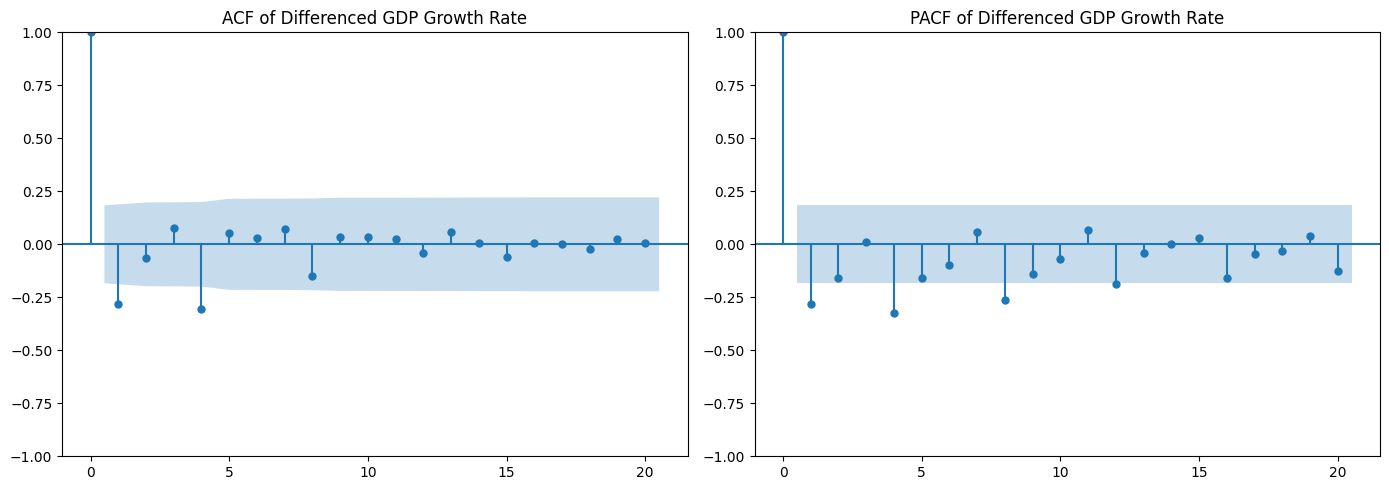

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(data_diff, lags=20, ax=axes[0],
         title='ACF of Differenced GDP Growth Rate')

plot_pacf(data_diff, lags=20, ax=axes[1],
          title='PACF of Differenced GDP Growth Rate')

plt.tight_layout()
plt.show()

p is the longest spike in the blue shaded region pacf

q is the longest spike in the blue shaded region of acf

p = 4, q = 4, d = 1

Train/Test Split

Why: We keep the last 20 quarters (5 years) as test data. The model never sees this during training. This lets us fairly evaluate how well it forecasts.

In [ ]:
# Step 1 - reset index
data = data.reset_index()

# Step 2 - remove duplicate dates keeping the last entry
data = data.drop_duplicates(subset='DATE', keep='last')

# Step 3 - set datetime index
data['DATE'] = pd.to_datetime(data['DATE'])
data = data.set_index('DATE')

# Step 4 - confirm duplicates are gone
print(f"Duplicates remaining : {data.index.duplicated().sum()}")
print(f"Total rows           : {len(data)}")
print(data.index.dtype)
print(data.head())

Duplicates remaining : 0
Total rows           : 115
datetime64[ns]
            index  GDP_growth_rate  Recession  GDP_diff
DATE                                                   
1997-04-01      0         3.271867      False       NaN
1997-07-01      1         3.995211      False  0.723344
1997-10-01      2         4.010855      False  0.015644
1998-01-01      3         4.916954      False  0.906099
1998-04-01      4         5.858280      False  0.941326


In [ ]:
train = data['GDP_growth_rate'][:-20]
test  = data['GDP_growth_rate'][-20:]

print(f"Train period : {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test period  : {test.index[0].date()}  to {test.index[-1].date()}")
print(f"Train size   : {len(train)} quarters")
print(f"Test size    : {len(test)} quarters")

Train period : 1997-04-01 to 2020-10-01
Test period  : 2021-01-01  to 2025-10-01
Train size   : 95 quarters
Test size    : 20 quarters


Fit ARIMA on train data


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

arima_model  = ARIMA(train, order=(4, 1, 4))
arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:        GDP_growth_rate   No. Observations:                   95
Model:                 ARIMA(4, 1, 4)   Log Likelihood                -238.946
Date:                Mon, 30 Mar 2026   AIC                            495.891
Time:                        16:05:03   BIC                            518.781
Sample:                    04-01-1997   HQIC                           505.137
                         - 10-01-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2014      1.368     -0.147      0.883      -2.883       2.480
ar.L2         -0.1313      1.190     -0.110      0.912      -2.465       2.202
ar.L3          0.1700      0.868      0.196      0.8

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Generate ARIMA forecast
arima_forecast = arima_result.predict(start=len(train), end=len(train) + len(test) - 1)

# ARIMA metrics
arima_mae1 = mean_absolute_error(test, arima_forecast)
arima_mse1 = mean_squared_error(test, arima_forecast)
print("arima mae is:", arima_mae1)
print("arima mse is:", arima_mse1)

arima mae is: 5.011572241661895
arima mse is: 31.90010678490422


Fit SARIMA on train data

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model  = SARIMAX(train,
                        order=(4, 1, 4),
                        seasonal_order=(0, 1, 0, 4), # this is not the same p and q. it is P and Q, seasonal autoregressive. Changed Q from 4 to 0 to remove conflict at lag 4
                        enforce_stationarity=False,
                        enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

sarima_forecast = sarima_result.predict(start=len(train), end=len(train) + len(test) - 1)

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                    GDP_growth_rate   No. Observations:                   95
Model:             SARIMAX(4, 1, 4)x(0, 1, [], 4)   Log Likelihood                -223.829
Date:                            Mon, 30 Mar 2026   AIC                            465.658
Time:                                    16:05:03   BIC                            487.642
Sample:                                04-01-1997   HQIC                           474.500
                                     - 10-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2040      0.438     -0.466      0.641      -1.062       0.654
ar.L2         -0.1216      0.476   

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# SARIMA metrics
sarima_mae1 = mean_absolute_error(test, sarima_forecast)
sarima_mse1 = mean_squared_error(test, sarima_forecast)
print("sarima mae is:", sarima_mae1)
print("sarima mse is:", sarima_mse1)

sarima mae is: 12.818705370045151
sarima mse is: 197.65714625832794


plotting of sarima arima

In [ ]:
import plotly.graph_objs as go

fig = go.Figure()

# Training data
fig.add_trace(go.Scatter(
    x=train.index, y=train,
    name='Train Data',
    line=dict(color='blue', width=2)
))

# Actual test values
fig.add_trace(go.Scatter(
    x=test.index, y=test,
    name='Actual Test Data',
    line=dict(color='black', width=2)
))

# ARIMA forecast
fig.add_trace(go.Scatter(
    x=test.index, y=arima_forecast,
    name='ARIMA Forecast',
    line=dict(color='orange', width=2, dash='dash')
))

# SARIMA forecast
fig.add_trace(go.Scatter(
    x=test.index, y=sarima_forecast,
    name='SARIMA Forecast',
    line=dict(color='green', width=2, dash='dot')
))

fig.update_layout(
    title='ARIMA vs SARIMA — Forecast vs Actual Test Data',
    xaxis_title='Date',
    yaxis_title='GDP Growth Rate (%)',
    legend=dict(x=0, y=1)
)
fig.show()

***ARIMA is better here***

residual check

ARIMA's residuals look like white noise.

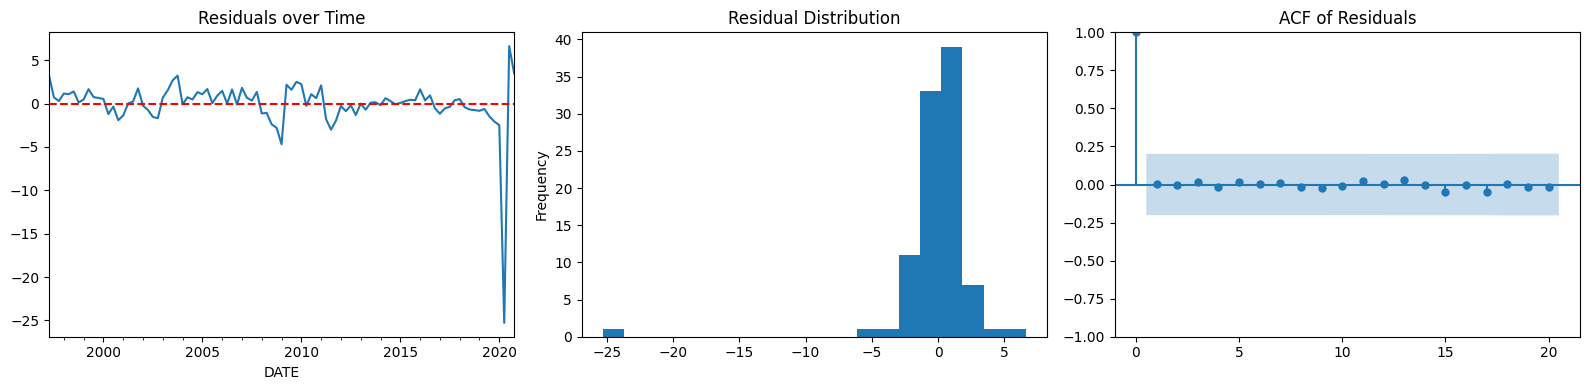

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Residual plot
arima_result.resid.plot(ax=axes[0], title='Residuals over Time')
axes[0].axhline(0, color='red', linestyle='--')

# 2. Residual histogram
arima_result.resid.plot(kind='hist', ax=axes[1],
                         bins=20, title='Residual Distribution')

# 3. ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(arima_result.resid.dropna(), lags=20,
         ax=axes[2], title='ACF of Residuals')

plt.tight_layout()
plt.show()

Refit the model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

final_model  = ARIMA(data['GDP_growth_rate'], order=(4, 1, 4))
final_result = final_model.fit()

print(final_result.summary())

                               SARIMAX Results                                
Dep. Variable:        GDP_growth_rate   No. Observations:                  115
Model:                 ARIMA(4, 1, 4)   Log Likelihood                -290.746
Date:                Mon, 30 Mar 2026   AIC                            599.492
Time:                        16:05:04   BIC                            624.118
Sample:                    04-01-1997   HQIC                           609.486
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4313      0.119     -3.636      0.000      -0.664      -0.199
ar.L2         -0.3001      0.198     -1.516      0.129      -0.688       0.088
ar.L3         -0.1746      0.272     -0.642      0.5

*forecasting of next 8 quarters*

In [ ]:
forecast_steps = 8

forecast_obj  = final_result.get_forecast(steps=forecast_steps)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int()

# Assign proper quarterly date index
import pandas as pd
forecast_index = pd.date_range(
    start='2026-01-01',
    periods=forecast_steps,
    freq='QS'
)
forecast_mean.index = forecast_index
forecast_ci.index   = forecast_index

print(forecast_mean)

2026-01-01    7.735796
2026-04-01    3.818936
2026-07-01    6.709117
2026-10-01    7.216720
2027-01-01    6.805511
2027-04-01    5.774717
2027-07-01    6.660778
2027-10-01    6.731107
Freq: QS-JAN, Name: predicted_mean, dtype: float64


In [ ]:
forecast_df = pd.DataFrame({
    'GDP_growth_rate' : forecast_mean,
    'lower_CI'        : forecast_ci.iloc[:, 0],
    'upper_CI'        : forecast_ci.iloc[:, 1]
})

forecast_df['Recession'] = (
    (forecast_df['GDP_growth_rate'] < 0) &
    (forecast_df['GDP_growth_rate'].shift(1) < 0)
)

print(forecast_df)

            GDP_growth_rate  lower_CI   upper_CI  Recession
2026-01-01         7.735796  1.874487  13.597106      False
2026-04-01         3.818936 -2.974602  10.612473      False
2026-07-01         6.709117 -0.607751  14.025985      False
2026-10-01         7.216720 -0.561078  14.994518      False
2027-01-01         6.805511 -1.121121  14.732144      False
2027-04-01         5.774717 -2.151689  13.701124      False
2027-07-01         6.660778 -1.283381  14.604938      False
2027-10-01         6.731107 -1.233397  14.695611      False


In [ ]:
# Force proper datetime index on forecast
forecast_index = pd.date_range(
    start  = '2026-01-01',
    periods = forecast_steps,
    freq   = 'QS'
)

forecast_df.index = forecast_index
data.index        = pd.to_datetime(data.index)

In [ ]:
fig = go.Figure()

# Historical data
fig.add_trace(go.Scatter(
    x=data.index,
    y=data['GDP_growth_rate'],
    name='Historical GDP Growth',
    line=dict(color='blue', width=2)
))

# Forecast line
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df['GDP_growth_rate'],
    name='Forecast',
    line=dict(color='green', width=2, dash='dash')
))

# Confidence interval band
fig.add_trace(go.Scatter(
    x=list(forecast_df.index) + list(forecast_df.index[::-1]),
    y=list(forecast_df['upper_CI']) + list(forecast_df['lower_CI'][::-1]),
    fill='toself',
    fillcolor='rgba(0, 200, 0, 0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Confidence Interval'
))

# Recession markers
recession_forecast = forecast_df[forecast_df['Recession']]
if len(recession_forecast) > 0:
    fig.add_trace(go.Scatter(
        x=recession_forecast.index,
        y=recession_forecast['GDP_growth_rate'],
        mode='markers',
        marker=dict(color='red', size=12, symbol='x'),
        name='Predicted Recession'
    ))
else:
    print("No recession predicted in forecast period")

# Vertical line
fig.add_vline(
    x=pd.Timestamp('2026-01-01').value,
    line_dash='dot',
    line_color='grey',
    annotation_text='Forecast Start',
    annotation_position='top right'
)

fig.update_layout(
    title='India GDP Growth — Historical + Forecast to 2027 (ARIMA)',
    xaxis_title='Date',
    yaxis_title='GDP Growth Rate (%)',
    legend=dict(x=0, y=1)
)

fig.show()

No recession predicted in forecast period
